# NIH Chest X-ray - Model Training

This notebook trains the models. The resulting weights are used in subsequent notebooks for: evaluation and explainable AI.

## Contents:
1. Environment Setup & Imports
2. Experiment Configuration
3. Device Configuration
4. Dataset Loading
5. Model Initialization
6. Model Complexity Analysis
7. Model Training
8. Training Curves Visualization
9. Model Checkpoint Loading
10. Training Summary Export

## 1. Environment Setup & Imports

This section initializes the environment, imports required libraries, and sets the global random seed for reproducibility across all experiments.

In [5]:
import sys

import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

import config
from dataset import get_dataloaders
from models import build_model
from train import train_model
from utils import seed_everything, plot_training_curves

## 2. Experiment Configuration

This section defines the experiment name and output directory structure. All outputs such as checkpoints, logs, and evaluation results will be stored under this experiment for reproducibility and comparison.

In [6]:
seed_everything()

# Choose experiment name (VERY important for thesis reproducibility)
EXPERIMENT_NAME = "exp_01_densenet_baseline"

config.set_experiment(EXPERIMENT_NAME)

print("Experiment:", config.EXPERIMENT_NAME)
print("Output dir:", config.OUTPUT_DIR)

Experiment: exp_01_densenet_baseline
Output dir: /Users/vesco/Documents/Projects/xray-master/outputs/exp_01_densenet_baseline


## 3. Device Configuration

This section selects the computation device (GPU, Apple MPS, or CPU) depending on available hardware.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() 
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")

device

device(type='mps')

## 4. Dataset Loading

This section loads the preprocessed NIH Chest X-ray dataset using the pipeline defined in the previous notebook. It returns train, validation, and test DataLoaders.

In [8]:
train_loader, val_loader, test_loader = get_dataloaders()

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

[dataset] Loading metadata ...
[dataset] Subset mode: 1002 train+val, 202 test images
[dataset] Train/val patient overlap: 0
[dataset] Split sizes - train: 894, val: 108, test: 202
Train batches: 28
Val batches: 4
Test batches: 7


## 5. Model Initialization

This section initializes the CNN (DenseNet-121) and Vision Transformer (ViT-B/16) models, pretrained on ImageNet.

In [9]:
model_cnn = build_model( "densenet121", pretrained=True).to(device)
print(model_cnn)

DenseNet121Classifier(
  (backbone): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-0

In [10]:
total_params_cnn = sum(p.numel() for p in model_cnn.parameters())
trainable_params_cnn = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)

print(f"Total params: {total_params_cnn:,}")
print(f"Trainable params: {trainable_params_cnn:,}")

Total params: 6,969,231
Trainable params: 6,969,231


In [11]:
model_vit = build_model("vit_b_16", pretrained=True).to(device)
print(model_vit)

ViTClassifier(
  (backbone): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          (ln_1)

In [12]:
total_params_vit = sum(p.numel() for p in model_vit.parameters())
trainable_params_vit = sum(p.numel() for p in model_vit.parameters() if p.requires_grad)

print(f"Total params: {total_params_vit:,}")
print(f"Trainable params: {trainable_params_vit:,}")

Total params: 85,810,191
Trainable params: 85,810,191


## 7. Model Training

This section trains the selected model using a multi-label classification pipeline with class-imbalance-aware loss functions, learning rate scheduling, and early stopping.

In [15]:
model = model_cnn

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name="densenet121"
)

[train] Using device: mps
  [train] Tuning stage -> full (trainable params: 6,969,231)
  Epoch 01/15 | train_loss=0.0500 train_AUROC=0.4840 train_AUPRC=0.0888 | val_loss=0.0560 val_AUROC=0.4870 val_AUPRC=0.1508 | lr=1.00e-04 | 19.6s
  [train] Saved best checkpoint based on val_auprc=0.1508
  Epoch 02/15 | train_loss=0.0395 train_AUROC=0.5364 train_AUPRC=0.0973 | val_loss=0.0577 val_AUROC=0.5265 val_AUPRC=0.1587 | lr=9.88e-05 | 19.0s
  [train] Saved best checkpoint based on val_auprc=0.1587
  Epoch 03/15 | train_loss=0.0368 train_AUROC=0.6049 train_AUPRC=0.1021 | val_loss=0.0551 val_AUROC=0.5324 val_AUPRC=0.1613 | lr=9.51e-05 | 19.1s
  [train] Saved best checkpoint based on val_auprc=0.1613
  Epoch 04/15 | train_loss=0.0365 train_AUROC=0.5893 train_AUPRC=0.0981 | val_loss=0.0543 val_AUROC=0.5261 val_AUPRC=0.1630 | lr=8.92e-05 | 19.1s
  [train] Saved best checkpoint based on val_auprc=0.1630
  Epoch 05/15 | train_loss=0.0360 train_AUROC=0.5655 train_AUPRC=0.1049 | val_loss=0.0531 val_AUR

## 8. Training Curves Visualization

This section visualizes training and validation performance over epochs, including loss, AUROC, and AUPRC trends.

[utils] Training curves saved -> /Users/vesco/Documents/Projects/xray-master/outputs/exp_01_densenet_baseline/results/densenet121_training_curves.png


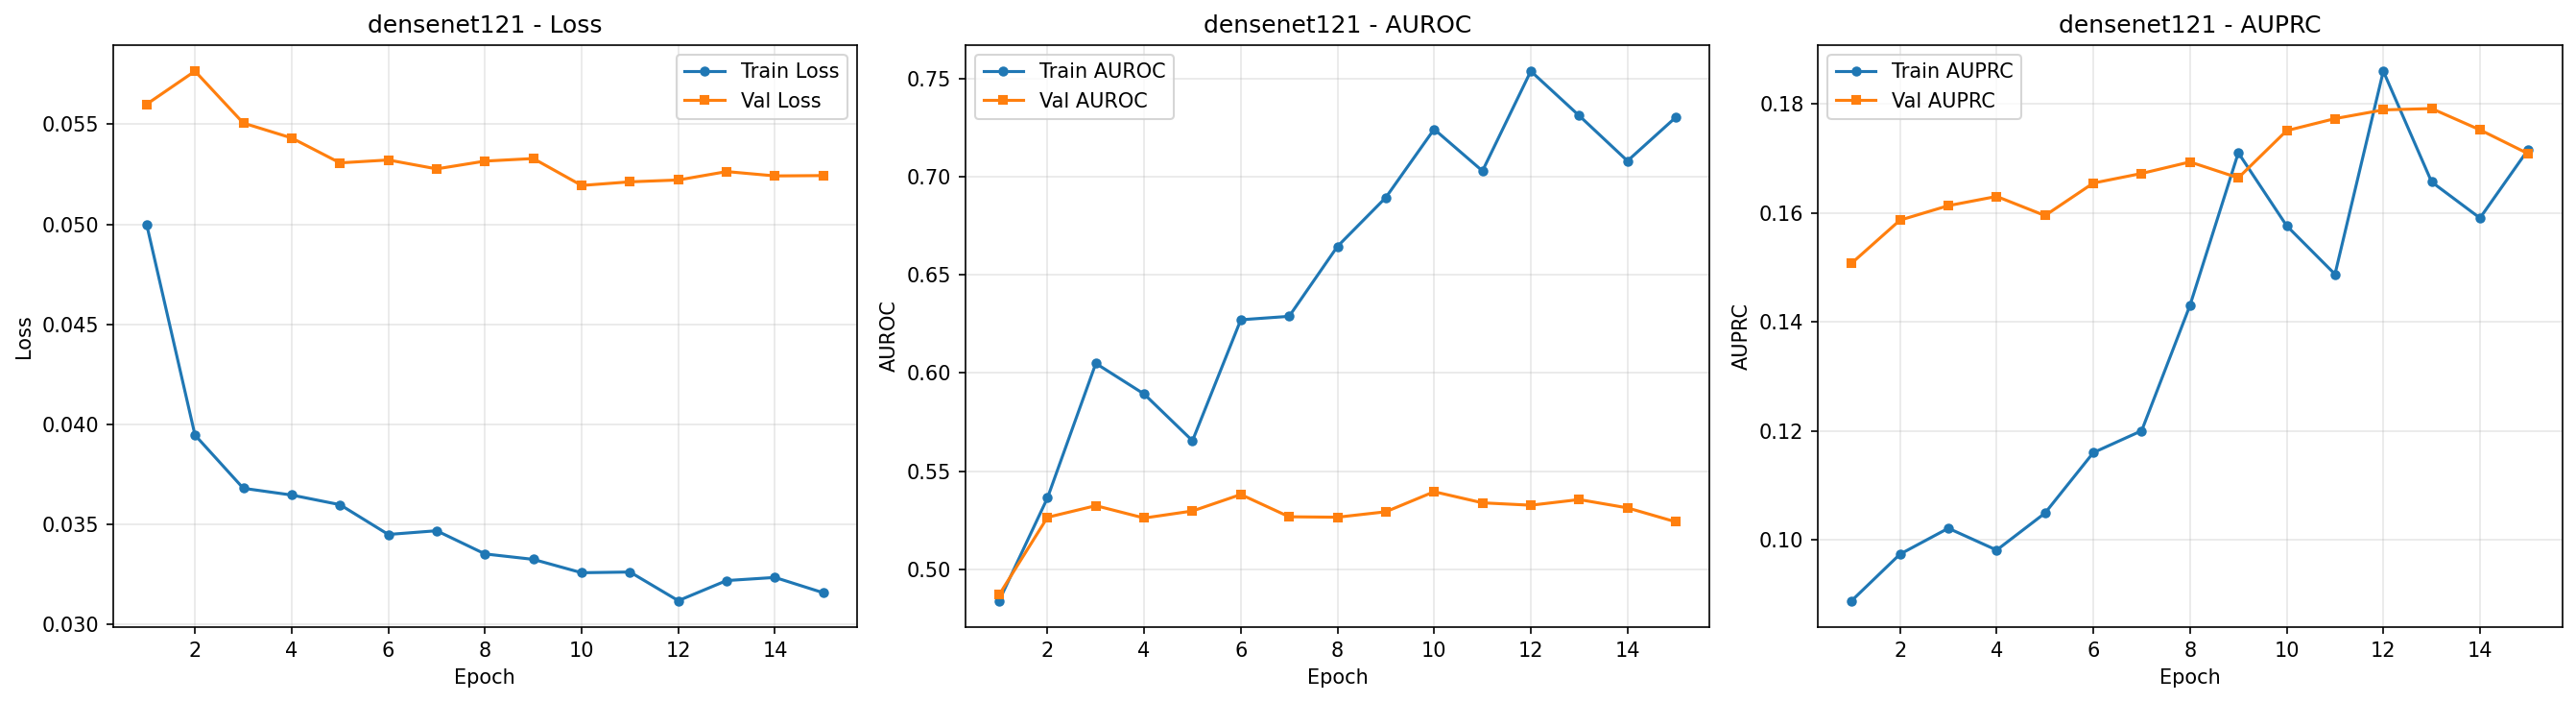

In [17]:
from IPython.display import Image, display

curve_path = plot_training_curves(history, "densenet121")
display(Image(filename=curve_path))

## 9. Model Checkpoint Loading

This section loads the best-performing model checkpoint selected during training based on the validation metric.

In [19]:
ckpt_path = config.CHECKPOINT_DIR / f"{"densenet121"}_best.pt"

model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

print("Loaded checkpoint:", ckpt_path)

Loaded checkpoint: /Users/vesco/Documents/Projects/xray-master/outputs/exp_01_densenet_baseline/checkpoints/densenet121_best.pt


## 10. Training Summary Export

This section saves a structured summary of the training run, including final performance metrics, for later comparison across experiments.

In [21]:
import json
from IPython.display import JSON, display

summary = {
    "model": "densenet121",
    "experiment": EXPERIMENT_NAME,
    "epochs_trained": len(history["train_loss"]),
    "final_train_loss": history["train_loss"][-1],
    "final_val_loss": history["val_loss"][-1],
    "final_val_auroc": history["val_auroc"][-1],
    "final_val_auprc": history["val_auprc"][-1],
}

summary_path = config.RESULTS_DIR / f"{"densenet121"}_training_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "model": "densenet121",
  "experiment": "exp_01_densenet_baseline",
  "epochs_trained": 15,
  "final_train_loss": 0.03156765109507296,
  "final_val_loss": 0.05243542307504901,
  "final_val_auroc": 0.5241535207712961,
  "final_val_auprc": 0.1708633308779986
}
